In [16]:
import librosa

test_audio_file = "03-01-03-02-01-02-02"

try:
    audio, sr = librosa.load(f"audio_files/{test_audio_file}.wav")
    audio = librosa.util.normalize(audio)
except Exception as e:
    print(f"Error occured: {e}")

librosa.get_duration(y=audio, sr=sr)

3.670340136054422

In [17]:
import pandas as pd

df = pd.read_csv("metadata.csv")
df.head()

,file_name,emotion,intensity,gender,statement
0,03-01-06-01-02-02-02,fearful,normal,female,Dogs are sitting by the door
1,03-01-05-01-02-01-16,angry,normal,female,Dogs are sitting by the door
2,03-01-08-01-01-01-14,surprised,normal,female,Kids are talking by the door
3,03-01-06-01-02-02-16,fearful,normal,female,Dogs are sitting by the door
4,03-01-05-01-02-01-02,angry,normal,female,Dogs are sitting by the door


In [18]:
df.loc[df["file_name"] == test_audio_file]

,file_name,emotion,intensity,gender,statement
1397,03-01-03-02-01-02-02,happy,strong,female,Kids are talking by the door


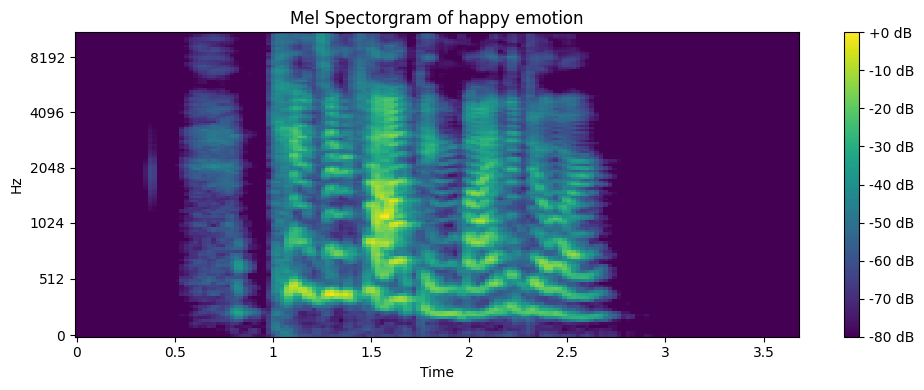

In [19]:
import matplotlib.pyplot as plt
import numpy as np

mel_spec = librosa.feature.melspectrogram(
        y=audio, 
        sr=sr, 
        n_mels=128,
        n_fft=2048,
        hop_length=512
    )
mel_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_db, x_axis='time', y_axis='mel', cmap='viridis')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectorgram of happy emotion")
plt.tight_layout()
plt.show()
    

In [20]:
sad_audio_file = "03-01-04-01-02-02-02"

try:
    sad_audio, sad_sr = librosa.load(f"audio_files/{sad_audio_file}.wav")
    sad_audio = librosa.util.normalize(sad_audio)
except Exception as e:
    print(f"Error occured: {e}")

librosa.get_duration(y=sad_audio, sr=sad_sr)

3.7704761904761903

In [21]:
df.loc[df["file_name"] == sad_audio_file]

,file_name,emotion,intensity,gender,statement
1128,03-01-04-01-02-02-02,sad,normal,female,Dogs are sitting by the door


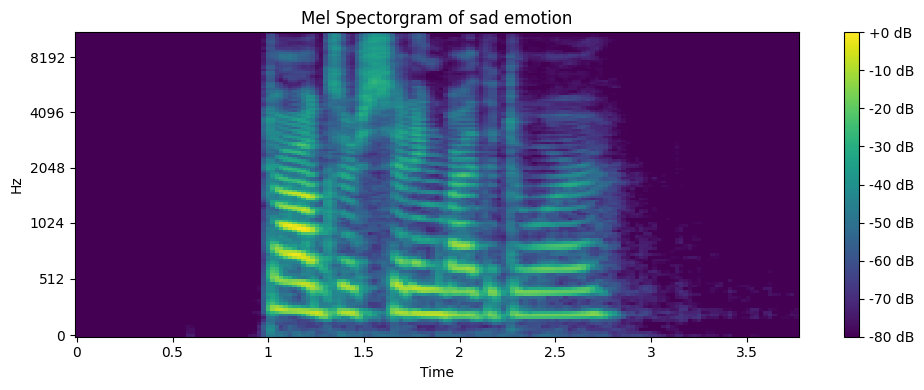

In [22]:
mel_spec_sad = librosa.feature.melspectrogram(
        y=sad_audio, 
        sr=sad_sr, 
        n_mels=128,
        n_fft=2048,
        hop_length=512
    )
mel_db_sad = librosa.power_to_db(mel_spec_sad, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_db_sad, x_axis='time', y_axis='mel', cmap='viridis')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectorgram of sad emotion")
plt.tight_layout()
plt.show()

In [24]:
import os
import glob
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [26]:
SOURCE_DIR = "audio_files"
SAMPLE_RATE = 22050
DURATION = 3
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION

def extract_mel_spectrogram(file_path):
    try:
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
        
        if len(y) > SAMPLES_PER_TRACK:
            y = y[:int(SAMPLES_PER_TRACK)]
        else:
            padding = int(SAMPLES_PER_TRACK) - len(y)
            offset = padding // 2
            y = np.pad(y, (offset, padding - offset), 'constant')
            
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        return mel_spec_db
    except:
        return None

data = []
labels = []

wav_files = glob.glob(os.path.join(SOURCE_DIR, "*.wav"))

print(f"Found {len(wav_files)} files. Processing...")

for file_path in wav_files:
    filename = os.path.basename(file_path)
    parts = filename.split('-')
    
    if len(parts) >= 3:
        emotion_code = int(parts[2]) - 1
        spec = extract_mel_spectrogram(file_path)
        
        if spec is not None:
            data.append(spec)
            labels.append(emotion_code)

X = np.array(data)
y = np.array(labels)

X = X[..., np.newaxis]
y = to_categorical(y)

print("Data shape:", X.shape)
print("Labels shape:", y.shape)

Found 1440 files. Processing...
Data shape: (1440, 128, 130, 1)
Labels shape: (1440, 8)


d:\C_analyzer\nlp_project\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 39s 962ms/step - accuracy: 0.1478 - loss: 20.1024 - val_accuracy: 0.1354 - val_loss: 240.4453 - learning_rate: 0.0010
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 33s 918ms/step - accuracy: 0.1717 - loss: 3.1971 - val_accuracy: 0.1354 - val_loss: 75.5282 - learning_rate: 0.0010
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 41s 909ms/step - accuracy: 0.1706 - loss: 3.1861 - val_accuracy: 0.1250 - val_loss: 16.4162 - learning_rate: 0.0010
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 33s 912ms/step - accuracy: 0.1943 - loss: 3.0901 - val_accuracy: 0.1354 - val_loss: 8.4098 - learning_rate: 0.0010
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 33s 907ms/step - accuracy: 0.1975 - loss: 3.0245 - val_accuracy: 0.1354 - val_loss: 3.7061 - learning_rate: 0.0010
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 33s 916ms/step - accuracy: 0.1965 - loss: 3.0554 - val_accuracy: 0.1910 - val_loss: 6.3651 - learning_rate: 0.0010
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 33s 910ms/step - accuracy: 0.234

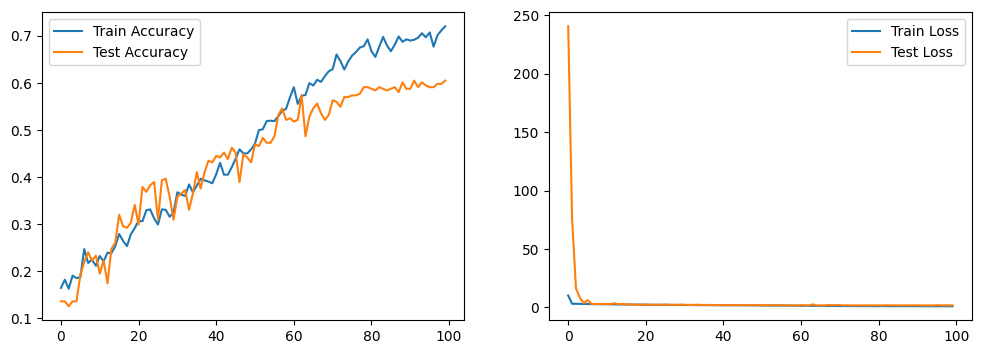

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step


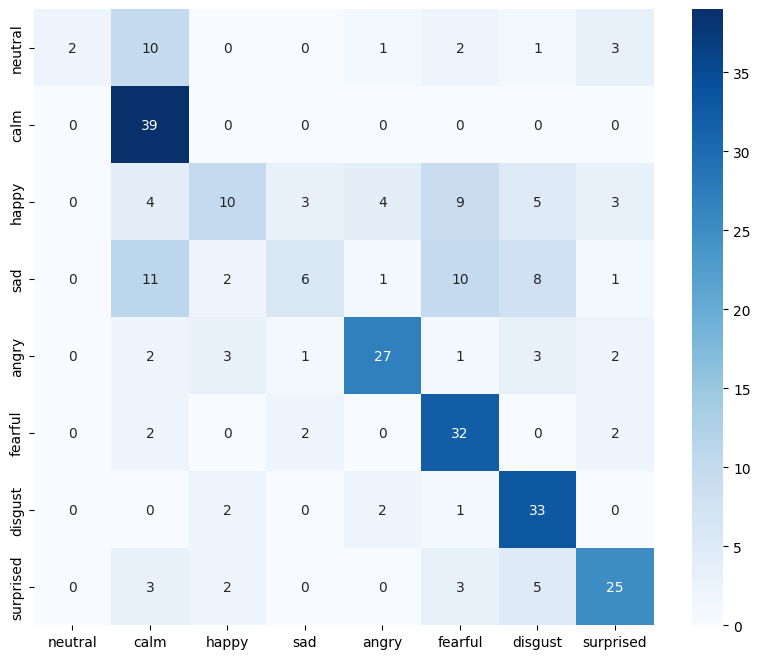

              precision    recall  f1-score   support

     neutral       1.00      0.11      0.19        19
        calm       0.55      1.00      0.71        39
       happy       0.53      0.26      0.35        38
         sad       0.50      0.15      0.24        39
       angry       0.77      0.69      0.73        39
     fearful       0.55      0.84      0.67        38
     disgust       0.60      0.87      0.71        38
   surprised       0.69      0.66      0.68        38

    accuracy                           0.60       288
   macro avg       0.65      0.57      0.53       288
weighted avg       0.63      0.60      0.56       288



In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

with tf.device('/GPU:0'):
    model = Sequential([
        Conv2D(64, (3, 3), activation='relu', input_shape=(128, 130, 1), kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.3),

        Conv2D(128, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.3),

        Conv2D(256, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.4),

        Flatten(),
        Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        Dropout(0.4),
        Dense(8, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    lr_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience=5, verbose=1, factor=0.5, min_lr=0.00001)
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)

    history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[lr_reduction, early_stopping])

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.legend()
plt.show()

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

emotion_names = ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_names, yticklabels=emotion_names)
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=emotion_names))

In [2]:
import os
import librosa
import soundfile as sf
import numpy as np

SOURCE_DIR = "audio_files"
AUGMENTED_DIR = "augmented_audio"

def add_noise(data):
    noise_amp = 0.035*np.random.uniform()*np.amax(data)
    data = data + noise_amp*np.random.normal(size=data.shape[0])
    return data

def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(y=data, rate=rate)

def pitch(data, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(y=data, sr=sampling_rate, n_steps=pitch_factor)

if not os.path.exists(AUGMENTED_DIR):
    os.makedirs(AUGMENTED_DIR)

for file in os.listdir(SOURCE_DIR):
    file_path = os.path.join(SOURCE_DIR, file)
    data, sr = librosa.load(file_path)
    
    # 1. Original (Copy it)
    sf.write(os.path.join(AUGMENTED_DIR, f"orig_{file}"), data, sr)
    
    # 2. Noisy
    noisy_data = add_noise(data)
    sf.write(os.path.join(AUGMENTED_DIR, f"noise_{file}"), noisy_data, sr)
    
    # 3. Stretch (Fast)
    stretch_data = stretch(data, rate=1.2)
    sf.write(os.path.join(AUGMENTED_DIR, f"stretch_{file}"), stretch_data, sr)
    
    # 4. Pitch Shift
    pitch_data = pitch(data, sr)
    sf.write(os.path.join(AUGMENTED_DIR, f"pitch_{file}"), pitch_data, sr)

print(" Done! Now point your training code to 'augmented_audio' folder!")

 Done! Now point your training code to 'augmented_audio' folder!


In [ ]:
import librosa
import numpy as np

# 1. SETTINGS
TEST_FILE = "test_voice.wav" # <--- YOUR FILE NAME HERE
SAMPLE_RATE = 22050
DURATION = 3
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION

def predict_emotion(file_path, model):
    # 1. Load and Preprocess (Exactly like training)
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
    
    # Fix length to 3 seconds
    if len(y) > SAMPLES_PER_TRACK:
        y = y[:int(SAMPLES_PER_TRACK)]
    else:
        padding = int(SAMPLES_PER_TRACK) - len(y)
        offset = padding // 2
        y = np.pad(y, (offset, padding - offset), 'constant')
        
    # Create Spectrogram
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    # Reshape for CNN (1, 128, 130, 1)
    mel_spec_db = mel_spec_db[np.newaxis, ..., np.newaxis]
    
    # 2. Predict
    prediction = model.predict(mel_spec_db)
    predicted_index = np.argmax(prediction)
    confidence = np.max(prediction) * 100
    
    emotions = ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']
    predicted_emotion = emotions[predicted_index]
    
    return predicted_emotion, confidence

# --- RUN IT ---
emotion, conf = predict_emotion(TEST_FILE, model)
print(f"Result: I am {conf:.1f}% sure you are {emotion.upper()}!")